# Visualización de imágenes y mapas de color

Adicional a las gráficas 2D o 3D convencionales, en ocasiones podremos requerir la visualización de imágenes o mapas de color para nuestros proyectos de Ciencia de Datos y Machine Learning. Veamos cómo hacerlo.

## 1. Visualización de imágenes

Matplotlib permite visualizar imágenes en escala de grises (arreglos de *Alto x Ancho* y almacenados en formato *uint8*) o a color en formato RGB (arreglos de *Alto x Ancho x 3*):

In [1]:
# Importemos Matplotlib y la librería Numpy
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# En este caso, para poder leer una imagen desde el disco duro debemos contar con una librería
# para la lectura de imágenes desde Python. Podemos usar Pillow
!pip install Pillow


[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [3]:
# Primero leamos una imagen en escala de grises que viene pre-instalada con Pillow
from PIL import Image

img = np.asarray(Image.open('amsterdam_grayscale.jpg'))
type(img)

numpy.ndarray

In [4]:
# Y verifiquemos su tamaño
img.shape

(1273, 1920)

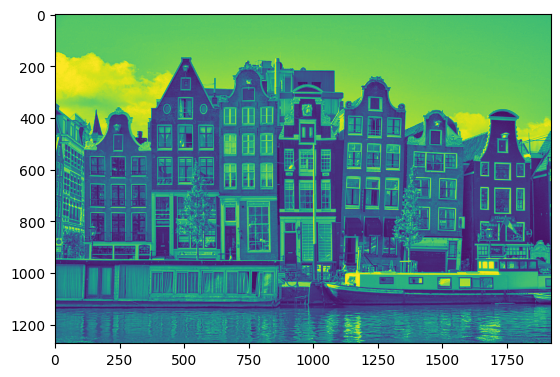

In [5]:
# Y ahora podemos visualizarla usando una sintaxis similar a la usada para generar las gráficas
fig, ax = plt.subplots()
ax.imshow(img);

Aunque la imagen que acabamos de visualizar se encuentra en escala de grises, por defecto Matplotlib le agrega un color falso conocido como **mapa de color**.

Para visualizarla en escala de grises debemos especificar el mapa de color *gray* usando el argumento `cmap`:

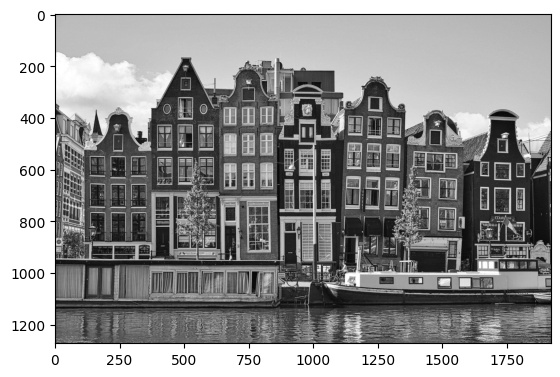

In [6]:
# Por defecto Matplotlib asigna un "mapa de color"
fig, ax = plt.subplots()
ax.imshow(img, cmap='gray');

Y podemos usar exactamente la misma sintaxis para visualizar una imagen RGB:

In [7]:
# Leamos la imagen y verifiquemos que se trata de un arreglo de alto x ancho x 3
img = np.asarray(Image.open('amsterdam.jpg'))
img.shape

(1273, 1920, 3)

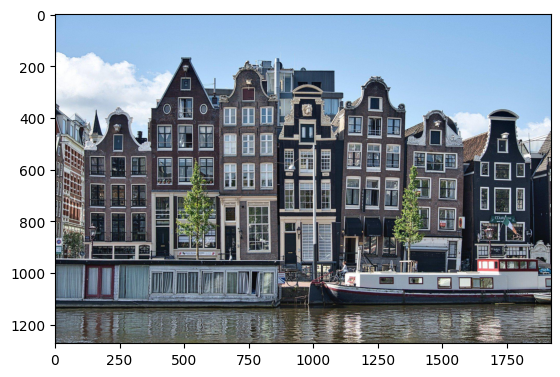

In [8]:
# Y ahora podemos visualizarla con Matplotlib sin necesidad de especificar el mapa de color
fig, ax = plt.subplots()
ax.imshow(img);

## 2. Visualización de mapas de color

En ocasiones tenemos datos donde la información está contenida en una arreglo de 3 dimensiones, pero resulta más fácil de interpretación si hacemos una gráfica 2D y codificamos la tercera dimensión usando colores. Estos se conocen como mapas de color.

Un ejemplo de esto son las **matrices de correlación**: cuando analizamos datos estructurados (en formato tabular) en ocasiones queremos ver si existe algún tipo de relación entre las diferentes columnas del set de datos (donde cada columna representa una variable determinada.

Para medir este grado de similitud lo que se hace es calcular la **correlación** entre las columnas. Esta correlación arroja un valor entre -1 y 1 indicando el grado de similitud:

- -1: los datos tienen un comportamiento totalmente opuesto
- 0: no hay similitud
- 1: los datos comparados son idénticos

Y el resultado de esta correlación se puede almacenar precisamente en una matriz de correlación, donde:

- Las filas y las columnas representan las variables entre las cuales se calcula la correlación
- Cada celda tiene un valor entre -1 y 1 indicando el grado de correlación

En estos casos resulta fácil interpretar la información contenida en la matriz de correlación usando un mapa de color:

In [9]:
# Ejemplo: creemos una matriz de correlación de 4x4 (es decir que compararemos 4 variables
# consigo mismas y entre sí)
matriz = np.array([
    [1.0, -0.8, 0.8, 0.1],
    [-0.8, 1.0, 0.7, 0.6],
    [0.8, 0.7, 1, -0.1],
    [0.1, 0.6, -0.1, 1]
])

Si imprimimos la matriz en pantalla tendremos la información esencial, pero esta no resulta fácil de interpretar:

In [10]:
matriz

array([[ 1. , -0.8,  0.8,  0.1],
       [-0.8,  1. ,  0.7,  0.6],
       [ 0.8,  0.7,  1. , -0.1],
       [ 0.1,  0.6, -0.1,  1. ]])

Pero esta interpretación resulta mucho más sencilla si codificamos cada valor de la matriz con un color, es decir si usamos un mapa de color:

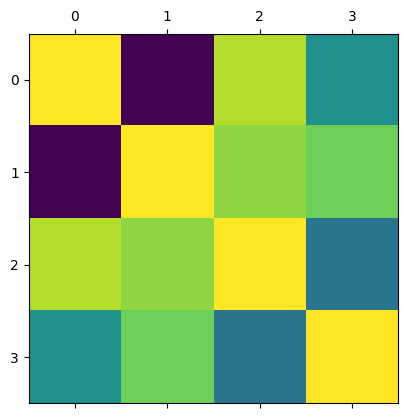

In [11]:
# Primero creamos la figura y los axes, como lo hemos hecho en todos los casos anteriores
fig, ax = plt.subplots()

# Y ahora usamos la función "matshow" para mostrar la matriz como un mapa de color
ax.matshow(matriz);

Aunque mejora un poco la visualización, aún resulta un poco complicada la interpretación. En el caso de los mapas de color es clave elegir adecuadamente el [mapa de color](https://matplotlib.org/stable/tutorials/colors/colormaps.html):

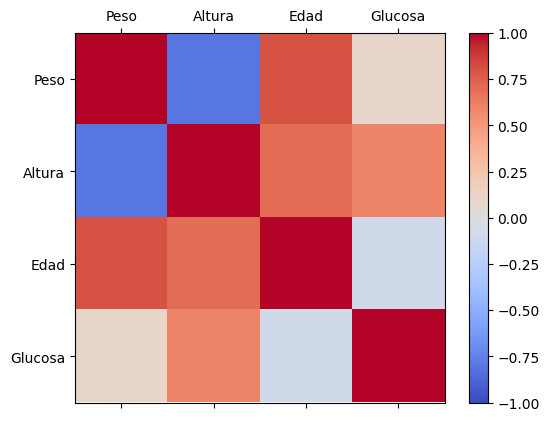

In [14]:
# Usemos por ejemplo el mapa de color "coolwarm"
fig, ax = plt.subplots()
mapa = ax.matshow(matriz, vmin=-1, vmax=1, cmap='coolwarm');

# Y añadamos una barra de color para facilitar la interpretación
fig.colorbar(mapa)

# Y personalicemos los nombres de los ticks verticales y horizontales
positions = [0, 1, 2, 3]
labels = ['Peso', 'Altura', 'Edad', 'Glucosa']
ax.set_xticks(positions, labels)
ax.set_yticks(positions, labels);

Y gracias a este simple mapa de color ya resulta mucho más sencillo interpretar el contenido de la matriz de correlación:

- Estamos comparando las variables 1 a 4 consigo mismas y con las demás.
- Cada celda de la matriz indica una de estas correlaciones. Ejemplo: la fila "Var. 2", columna "Var. 3" indica el resultado de calcular la correlación entre la variable 2 y la 3
- La matriz es simétrica: da lo mismo calcular la correlación entre "Var. 4" y "Var. 1" que entre "Var. 1" y "Var. 4"
- El mapa de colores seleccionado permite ver fácilmente niveles bajos y altos de correlación (bajos: tonalidades azules, altos: tonalidades rojas)
- Según esto:
  - En la diagonal principal todas las correlaciones son máximas (rojo == 1) pues estamos comparando cada variable consigo misma
  - Las variables 1 y 2 tienen niveles de correlación inversos (tonalidad azul, cercana a -1)
  - Mientras que las variables 1 y 3 o 2 y 4 tienen altos niveles de correlación (tonalidades rojas, cercanas a 1)